# BIO-INSPIRED OPTIMISATION & NEURAL NETWORKS

 =============================================================
 
 Contents:
   1. Particle Swarm Optimisation — Griewank benchmark
   2. RBF Neural Network — from scratch (Moore-Penrose pseudoinverse)
   3. Multi-Armed Bandit Simulation — epsilon-greedy vs greedy vs random
 
 =============================================================


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import pinv

np.random.seed(42)

PART 1: PARTICLE SWARM OPTIMISATION — Griewank Function
  PSO Iter  50/200 | Best fitness: 0.013215
  PSO Iter 100/200 | Best fitness: 0.007396
  PSO Iter 150/200 | Best fitness: 0.007396
  PSO Iter 200/200 | Best fitness: 0.007396

PSO Result:
  Best position : [ 3.14002262 -4.43844455]
  Best value    : 0.00739604  (true minimum = 0.0)


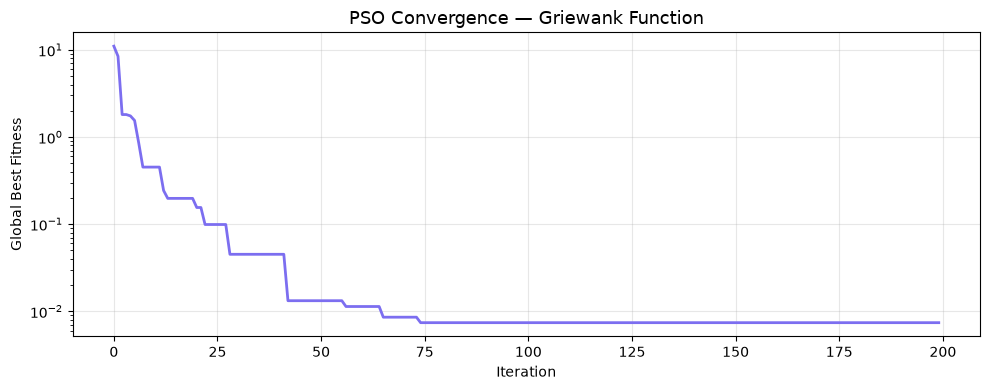

  [Saved: pso_convergence.png]


In [2]:
# =============================================================
# PART 1: PARTICLE SWARM OPTIMISATION (PSO)
# Benchmark: Griewank function
# Global minimum = 0 at origin
# f(x) = sum(x^2/4000) - prod(cos(x/sqrt(i))) + 1
# =============================================================

def griewank(x):
    """Griewank benchmark function. Global minimum = 0 at x = [0,0,...,0]"""
    n = len(x)
    sum_term  = np.sum(x**2) / 4000
    prod_term = np.prod([np.cos(x[i] / np.sqrt(i+1)) for i in range(n)])
    return sum_term - prod_term + 1


def pso(func, n_dims=2, n_particles=30, n_iter=200,
        w=0.7, c1=1.5, c2=1.5,
        bounds=(-600, 600)):
    """
    Particle Swarm Optimisation.
    w  = inertia weight
    c1 = cognitive coefficient (personal best)
    c2 = social coefficient (global best)
    """
    lo, hi = bounds

    # Initialise positions and velocities
    positions  = np.random.uniform(lo, hi, (n_particles, n_dims))
    velocities = np.random.uniform(-(hi-lo), (hi-lo), (n_particles, n_dims))

    personal_best_pos = positions.copy()
    personal_best_val = np.array([func(p) for p in positions])

    global_best_idx = np.argmin(personal_best_val)
    global_best_pos = personal_best_pos[global_best_idx].copy()
    global_best_val = personal_best_val[global_best_idx]

    history = []

    for iteration in range(n_iter):
        r1 = np.random.rand(n_particles, n_dims)
        r2 = np.random.rand(n_particles, n_dims)

        # Update velocities
        velocities = (w * velocities
                      + c1 * r1 * (personal_best_pos - positions)
                      + c2 * r2 * (global_best_pos   - positions))

        # Update positions
        positions += velocities
        positions  = np.clip(positions, lo, hi)

        # Evaluate fitness
        fitness = np.array([func(p) for p in positions])

        # Update personal bests
        improved = fitness < personal_best_val
        personal_best_pos[improved] = positions[improved]
        personal_best_val[improved] = fitness[improved]

        # Update global best
        best_idx = np.argmin(personal_best_val)
        if personal_best_val[best_idx] < global_best_val:
            global_best_val = personal_best_val[best_idx]
            global_best_pos = personal_best_pos[best_idx].copy()

        history.append(global_best_val)

        if (iteration + 1) % 50 == 0:
            print(f"  PSO Iter {iteration+1:>3}/{n_iter} | "
                  f"Best fitness: {global_best_val:.6f}")

    return global_best_pos, global_best_val, history


print("=" * 60)
print("PART 1: PARTICLE SWARM OPTIMISATION — Griewank Function")
print("=" * 60)
best_pos, best_val, pso_history = pso(griewank, n_dims=2, n_particles=30, n_iter=200)
print(f"\nPSO Result:")
print(f"  Best position : {best_pos}")
print(f"  Best value    : {best_val:.8f}  (true minimum = 0.0)")

# Plot convergence
plt.figure(figsize=(10, 4))
plt.plot(pso_history, color='#7c6ef0', linewidth=2)
plt.title("PSO Convergence — Griewank Function", fontsize=13)
plt.xlabel("Iteration")
plt.ylabel("Global Best Fitness")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pso_convergence.png", dpi=120)
plt.show()
print("  [Saved: pso_convergence.png]")


PART 2: RBF NEURAL NETWORK (Moore-Penrose pseudoinverse)

RBF Network Result:
  Centres  : 15
  MSE      : 0.002462
  RMSE     : 0.049618


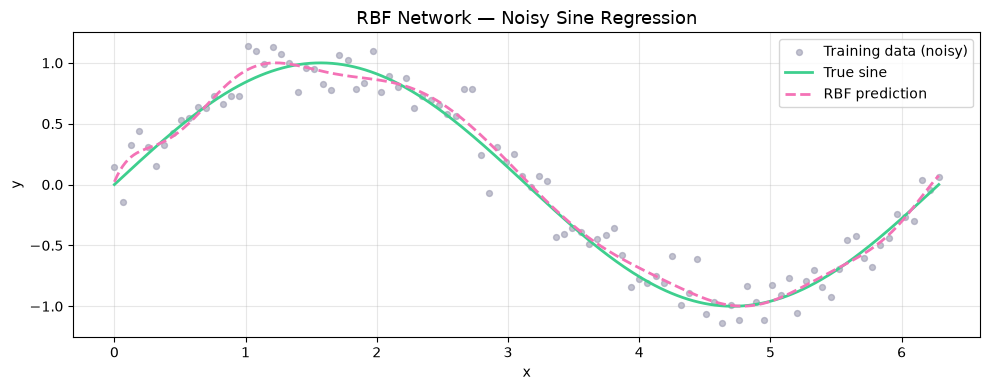

  [Saved: rbf_regression.png]


In [3]:
# =============================================================
# PART 2: RBF NEURAL NETWORK FROM SCRATCH
# Architecture: Input -> RBF hidden layer -> Linear output
# Training:     centres by k-means, widths by heuristic,
#               weights by Moore-Penrose pseudoinverse
# Demo dataset: noisy sine wave (regression)
# =============================================================

class RBFNetwork:
    """
    Radial Basis Function Neural Network.
    Training uses Moore-Penrose pseudoinverse (least squares, closed form).
    Kernel: Gaussian  phi(x,c) = exp(-||x-c||^2 / (2*sigma^2))
    """

    def __init__(self, n_centres=10):
        self.n_centres = n_centres
        self.centres   = None
        self.sigmas    = None
        self.weights   = None

    def _kmeans_centres(self, X, n_iter=100):
        """Simple k-means to find RBF centres."""
        idx      = np.random.choice(len(X), self.n_centres, replace=False)
        centres  = X[idx].copy()
        for _ in range(n_iter):
            dists    = np.linalg.norm(X[:, None] - centres[None, :], axis=2)
            labels   = np.argmin(dists, axis=1)
            new_c    = np.array([X[labels == k].mean(axis=0)
                                 if np.any(labels == k) else centres[k]
                                 for k in range(self.n_centres)])
            if np.allclose(centres, new_c, atol=1e-6):
                break
            centres = new_c
        return centres

    def _gaussian(self, X, centre, sigma):
        diff = X - centre
        return np.exp(-np.sum(diff**2, axis=1) / (2 * sigma**2))

    def _design_matrix(self, X):
        """Build design matrix Phi [n_samples x (n_centres+1)]."""
        Phi = np.zeros((len(X), self.n_centres + 1))
        Phi[:, 0] = 1.0  # bias column
        for j in range(self.n_centres):
            Phi[:, j+1] = self._gaussian(X, self.centres[j], self.sigmas[j])
        return Phi

    def fit(self, X, y):
        X = np.atleast_2d(X) if X.ndim == 1 else X
        # Step 1: find centres
        self.centres = self._kmeans_centres(X)
        # Step 2: widths — heuristic: d_max / sqrt(2*K)
        dists        = np.linalg.norm(
            self.centres[:, None] - self.centres[None, :], axis=2)
        d_max        = dists.max()
        sigma        = d_max / np.sqrt(2 * self.n_centres)
        self.sigmas  = np.full(self.n_centres, sigma)
        # Step 3: weights via Moore-Penrose pseudoinverse
        Phi          = self._design_matrix(X)
        self.weights = pinv(Phi) @ y

    def predict(self, X):
        X   = np.atleast_2d(X) if X.ndim == 1 else X
        Phi = self._design_matrix(X)
        return Phi @ self.weights


print("\n" + "=" * 60)
print("PART 2: RBF NEURAL NETWORK (Moore-Penrose pseudoinverse)")
print("=" * 60)

# Generate noisy sine wave dataset
X_train = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_train = np.sin(X_train.ravel()) + np.random.normal(0, 0.15, 100)

X_test  = np.linspace(0, 2*np.pi, 300).reshape(-1, 1)
y_true  = np.sin(X_test.ravel())

# Train
rbf = RBFNetwork(n_centres=15)
rbf.fit(X_train, y_train)
y_pred = rbf.predict(X_test)

mse = np.mean((y_pred - y_true)**2)
rmse = np.sqrt(mse)
print(f"\nRBF Network Result:")
print(f"  Centres  : {rbf.n_centres}")
print(f"  MSE      : {mse:.6f}")
print(f"  RMSE     : {rmse:.6f}")

# Plot
plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, s=18, alpha=0.6, color='#9a9ab0', label='Training data (noisy)')
plt.plot(X_test, y_true,  color='#3ecf8e', linewidth=2, label='True sine')
plt.plot(X_test, y_pred,  color='#f472b6', linewidth=2, linestyle='--', label='RBF prediction')
plt.title("RBF Network — Noisy Sine Regression", fontsize=13)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rbf_regression.png", dpi=120)
plt.show()
print("  [Saved: rbf_regression.png]")


PART 3: MULTI-ARMED BANDIT SIMULATION
Running 500 independent runs per strategy...

  Epsilon-Greedy (ε=0.1)
    Avg reward (last 100 steps)   : 1.3850
    % optimal action (last 100)   : 79.6%

  Epsilon-Greedy (ε=0.01)
    Avg reward (last 100 steps)   : 1.3627
    % optimal action (last 100)   : 62.5%

  Greedy (ε=0)
    Avg reward (last 100 steps)   : 1.0395
    % optimal action (last 100)   : 34.0%

  Random
    Avg reward (last 100 steps)   : -0.0129
    % optimal action (last 100)   : 9.9%


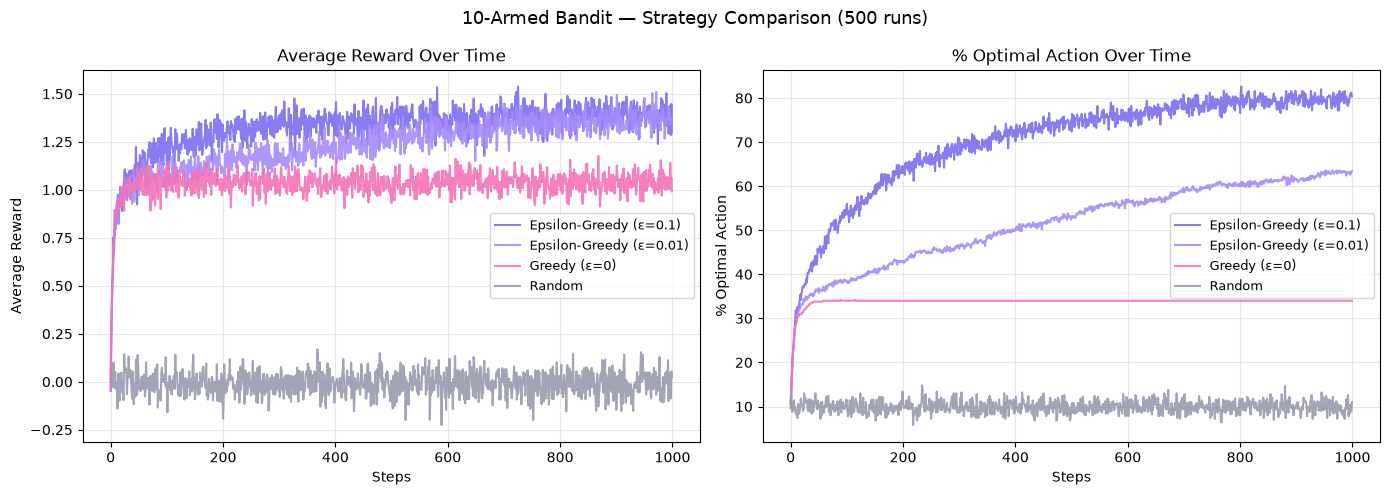


  [Saved: bandit_comparison.png]

ALL THREE SECTIONS COMPLETE
Output files: pso_convergence.png, rbf_regression.png, bandit_comparison.png


In [4]:
# =============================================================
# PART 3: MULTI-ARMED BANDIT SIMULATION
# Strategies: Epsilon-Greedy | Greedy (epsilon=0) | Random
# Environment: 10-arm bandit, true values drawn from N(0,1)
# =============================================================

class MultiArmedBandit:
    """k-armed bandit with stationary Gaussian rewards."""

    def __init__(self, k=10):
        self.k          = k
        self.true_values = np.random.randn(k)   # true action values

    def pull(self, arm):
        """Return a noisy reward from the chosen arm."""
        return self.true_values[arm] + np.random.randn()

    @property
    def optimal_arm(self):
        return np.argmax(self.true_values)


def run_bandit(strategy, epsilon, k=10, n_steps=1000, n_runs=500):
    """
    Run a multi-armed bandit simulation.
    strategy: 'epsilon_greedy' | 'greedy' | 'random'
    Returns average reward and % optimal action per step.
    """
    avg_rewards  = np.zeros(n_steps)
    pct_optimal  = np.zeros(n_steps)

    for _ in range(n_runs):
        bandit       = MultiArmedBandit(k=k)
        Q            = np.zeros(k)   # estimated action values
        N            = np.zeros(k)   # action counts

        for step in range(n_steps):
            # Action selection
            if strategy == 'random':
                action = np.random.randint(k)
            elif strategy == 'greedy':
                action = np.argmax(Q)
            else:  # epsilon-greedy
                if np.random.rand() < epsilon:
                    action = np.random.randint(k)
                else:
                    action = np.argmax(Q)

            reward = bandit.pull(action)
            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]  # incremental mean

            avg_rewards[step] += reward
            if action == bandit.optimal_arm:
                pct_optimal[step] += 1

    return avg_rewards / n_runs, (pct_optimal / n_runs) * 100


print("\n" + "=" * 60)
print("PART 3: MULTI-ARMED BANDIT SIMULATION")
print("=" * 60)
print("Running 500 independent runs per strategy...")

configs = [
    ('Epsilon-Greedy (ε=0.1)', 'epsilon_greedy', 0.10),
    ('Epsilon-Greedy (ε=0.01)','epsilon_greedy', 0.01),
    ('Greedy (ε=0)',            'greedy',         0.00),
    ('Random',                  'random',         1.00),
]

results = {}
for label, strategy, eps in configs:
    rewards, optimal = run_bandit(strategy, eps)
    results[label] = {'rewards': rewards, 'optimal': optimal}
    final_reward    = rewards[-100:].mean()
    final_optimal   = optimal[-100:].mean()
    print(f"\n  {label}")
    print(f"    Avg reward (last 100 steps)   : {final_reward:.4f}")
    print(f"    % optimal action (last 100)   : {final_optimal:.1f}%")

# Plot
colours = ['#7c6ef0','#a78bfa','#f472b6','#9a9ab0']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for (label, _), colour in zip([(k,v) for k,v in results.items()], colours):
    ax1.plot(results[label]['rewards'], color=colour, linewidth=1.5, label=label, alpha=0.9)
    ax2.plot(results[label]['optimal'], color=colour, linewidth=1.5, label=label, alpha=0.9)

ax1.set_title("Average Reward Over Time", fontsize=12)
ax1.set_xlabel("Steps"); ax1.set_ylabel("Average Reward")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.set_title("% Optimal Action Over Time", fontsize=12)
ax2.set_xlabel("Steps"); ax2.set_ylabel("% Optimal Action")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle("10-Armed Bandit — Strategy Comparison (500 runs)", fontsize=13)
plt.tight_layout()
plt.savefig("bandit_comparison.png", dpi=120)
plt.show()
print("\n  [Saved: bandit_comparison.png]")

print("\n" + "=" * 60)
print("ALL THREE SECTIONS COMPLETE")
print("Output files: pso_convergence.png, rbf_regression.png, bandit_comparison.png")
print("=" * 60)